In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('OnlineRetail.csv')

In [166]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [167]:
##Retail Sales Data Analysis

#This project analyzes online retail transaction data to understand customer purchasing behavior, product performance, and revenue trends.

#Objectives:
#1. Identify top-selling products
#2. Analyze revenue distribution across countries
#3. Understand customer purchasing patterns
#4. Identify high-value customers

In [168]:
df.shape

(541909, 8)

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [170]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [171]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [172]:
df['Description'].shape

(541909,)

In [173]:
df['Description'].unique()

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER', ..., 'lost',
       'CREAM HANGING HEART T-LIGHT HOLDER',
       'PAPER CRAFT , LITTLE BIRDIE'], dtype=object)

In [174]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [175]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [176]:
### remove missing customerid
df = df.dropna(subset = ['CustomerID'])

In [177]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [178]:
### remove negative quantity
df = df[df['Quantity'] > 0]

In [179]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171
std,180.420210,22.096788,1713.169877
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [180]:
df = df[df['UnitPrice'] > 0]

In [181]:
### create a new column (Revenue)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [182]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [183]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [184]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month


In [185]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12


In [186]:
#Business Questions

#1. Which products generate the highest revenue?
#2. Which countries contribute the most sales?
#3. Who are the highest value customers?
#4. How does revenue change across months?
#5. What is the relationship between price and quantity?

In [187]:
#performing buisiness analysis
#top selling products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending= False).head(10)
top_products



Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

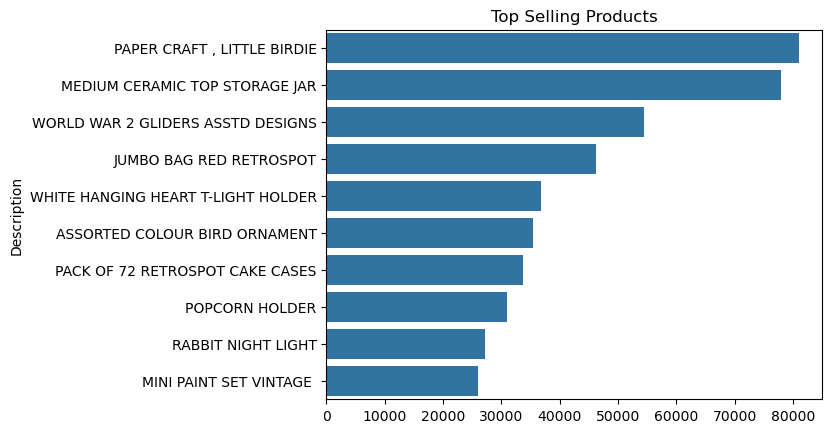

In [188]:
#visual representation of top products
sns.barplot(x = top_products.values,
            y = top_products.index)
plt.title('Top Selling Products')
plt.show()

In [189]:
#top revenue products
top_revenue = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending = False).head(10)
top_revenue


Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: TotalPrice, dtype: float64

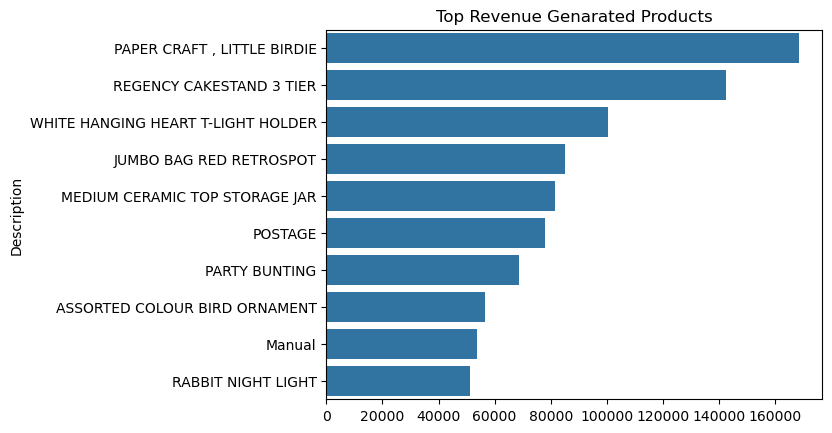

In [190]:
#visual representation of the top revenue generated products
sns.barplot(x = top_revenue.values,
            y = top_revenue.index)
plt.title('Top Revenue Genarated Products')
plt.show()

In [191]:
#revenue by country
top_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending = False).head(10)
top_country



Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64

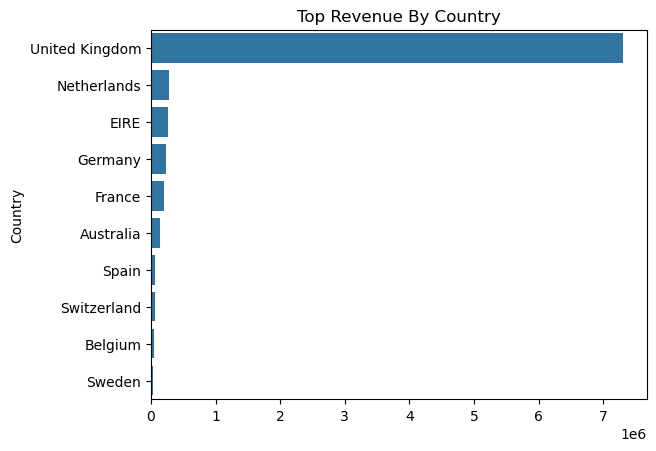

In [192]:
#visual represantation of the top revenue genarated country
sns.barplot(x = top_country.values,
            y = top_country.index)
plt.title('Top Revenue By Country')
plt.show()

In [193]:
#monthly revenue
monthly_revenue = df.groupby('Month')['UnitPrice'].sum()#.sort_values(ascending = False)
monthly_revenue


Month
1      66964.990
2      63185.760
3      88563.100
4      79005.481
5     102128.280
6      85274.730
7      75919.901
8      79423.830
9     119053.062
10    165849.980
11    185522.460
12    129109.040
Name: UnitPrice, dtype: float64

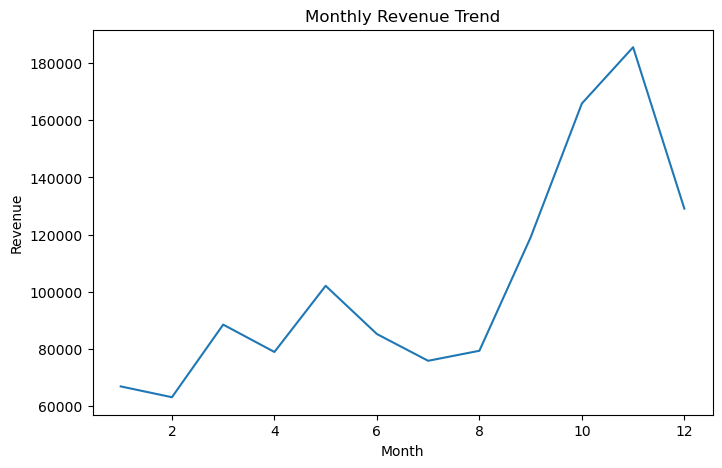

In [194]:
# visual representation of monthly_revenue by using line plot
monthly_revenue.plot(kind = 'line',figsize = (8,5))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

In [195]:
##customer analysis##

In [196]:
#top customers

In [197]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending = False).head(10)
top_customers


CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

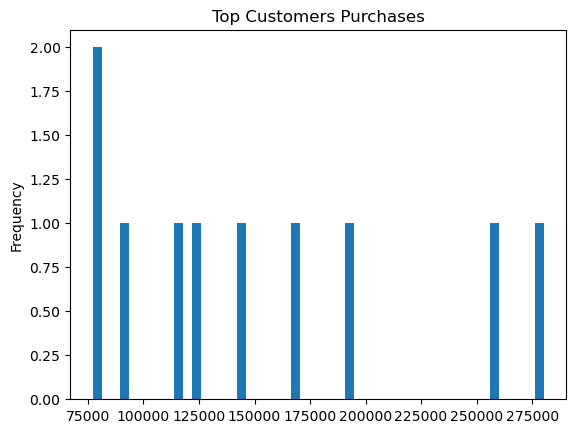

In [198]:
#visual representation of top customers
top_customers.plot(kind = 'hist',bins = 50)
plt.title('Top Customers Purchases')
plt.show()

In [199]:
#Key Insights

#1 A small number of products generate the majority of revenue.
#2 United Kingdom contributes the largest share of total sales.
#3 A small percentage of customers generate very high revenue.
#4 Sales increase significantly during the last quarter of the year.

In [200]:
#repeated customers
df['CustomerID'].value_counts()

CustomerID
17841.0    7847
14911.0    5675
14096.0    5111
12748.0    4595
14606.0    2700
           ... 
18184.0       1
13185.0       1
16073.0       1
17948.0       1
17846.0       1
Name: count, Length: 4338, dtype: int64

In [201]:
#RFM analysis (recency,frequency,monetary)

In [202]:
snapshot_date = df['InvoiceDate'].max()
snapshot_date
RFM = df.groupby('CustomerID').agg({'InvoiceDate' : lambda x :(snapshot_date - x.max()).days,'InvoiceNo' : 'count','TotalPrice':'sum'})
RFM.columns = ['Recency','Frequency','Monetary']
RFM.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


In [203]:
RFM['R_score'] = pd.qcut(RFM['Recency'], 4, labels=[4,3,2,1])
RFM['F_score'] = pd.qcut(RFM['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
RFM['M_score'] = pd.qcut(RFM['Monetary'], 4, labels=[1,2,3,4])

RFM['RFM_score'] = RFM[['R_score','F_score','M_score']].astype(str).sum(axis=1)

In [204]:
def segment_customer(score):
    if score >= '444':
        return 'Champions'
    elif score >= '344':
        return 'Loyal Customers'
    elif score >= '244':
        return 'Potential Loyalists'
    elif score >= '144':
        return 'At Risk'
    else:
        return 'Lost Customers'

RFM['Segment'] = RFM['RFM_score'].apply(segment_customer)

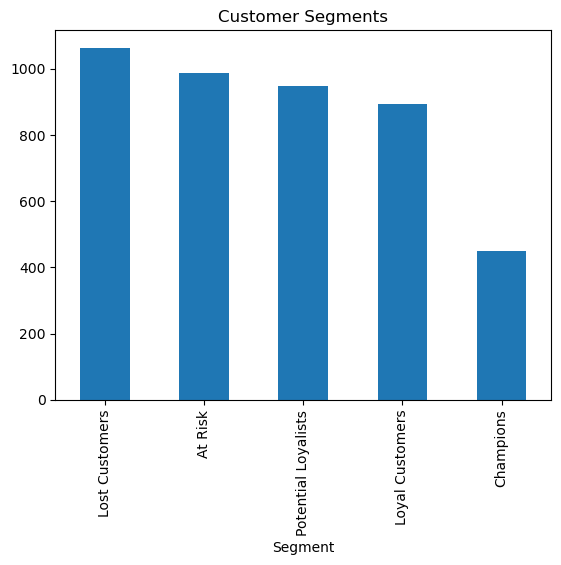

In [205]:
RFM['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

In [206]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month'],
      dtype='object')

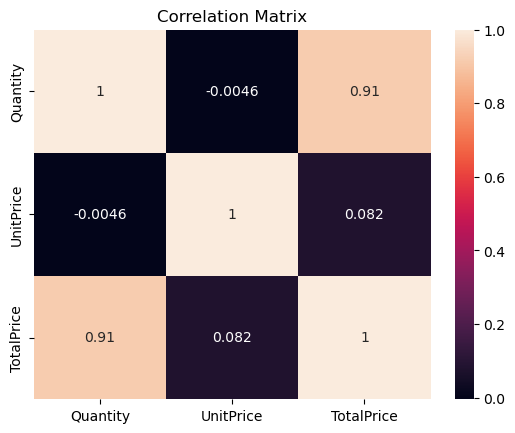

In [207]:
#correlation analysis
corr = df[['Quantity','UnitPrice','TotalPrice']].corr()
sns.heatmap(corr, annot = True)
plt.title('Correlation Matrix')
plt.show()

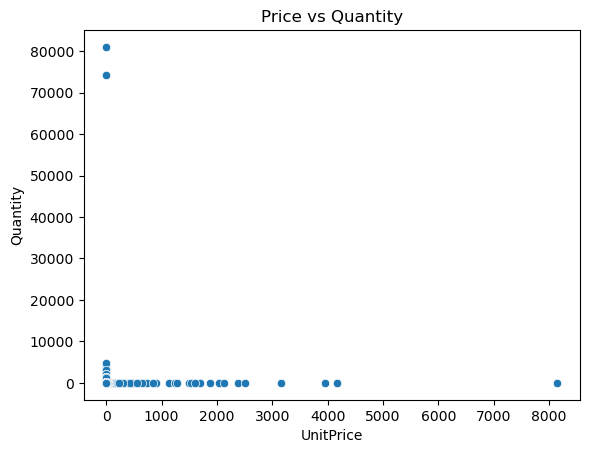

In [208]:
#price vs quantity analisys
sns.scatterplot(x = 'UnitPrice',
                y = 'Quantity',
                data = df)
plt.title('Price vs Quantity')
plt.show()

In [209]:
basket = df.groupby(['InvoiceNo','Description'])['Quantity'].sum().unstack().fillna(0)
basket.head(10)

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536372,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536373,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [210]:
#exporting processed data
df.to_csv('cleaned_retail_data.csv',index = False)

In [ ]:
#Conclusion

#The analysis highlights that a small group of customers and products drive a large portion of revenue.
#Businesses can use this insight to focus marketing efforts on high-value customers and optimize product inventory based on demand patterns.